In [2]:
from HLAN_xai import HLAN_xai
from BERT_HLAN_xai import BERT_HLAN_xai
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from gensim.models import Word2Vec
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from transformers import AutoModel, AutoTokenizer
from HLAN_xai_helper import *

c:\Users\samny\anaconda3\envs\HLAN\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in Test Data and Necessary pre-Trained Models to compare Explainability

#### Data:

In [ ]:
### Data paths
x_path =#test_word-emb.pt
y_path =#test_code-emb.pt
bluebert_x_path =#test_tok_bert_embed_bluebert.pt
bluebert_mask_path = #test_mask_bert_embed_bluebert.pt
bioclinical_x_path =#test_tok_bert_embed_bioclinical.pt
bioclinical_mask_path = #test_mask_bert_embed_bioclinical.pt
roberta_x_path =#test_tok_bert_embed_roberta.pt
roberta_mask_path = #test_mask_bert_embed_roberta.pt
top_ten_path = #top_ten.pkl

### Load in data
x = torch.load(x_path, weights_only = True)
y = torch.load(y_path, weights_only = True)
bluebert_x = torch.load(bluebert_x_path, weights_only = 'True')
bluebert_mask = torch.load(bluebert_mask_path, weights_only = 'True')
bioclinical_x = torch.load(bioclinical_x_path, weights_only = 'True')
bioclinical_mask = torch.load(bioclinical_mask_path, weights_only = 'True')
roberta_x = torch.load(roberta_x_path, weights_only = 'True')
roberta_mask = torch.load(roberta_mask_path, weights_only = 'True')

with open(top_ten_path, 'rb') as f:
    top_ten_df = pickle.load(f)

#### Models:

In [ ]:
#### Model Paths
word_model_path = #word-emb.model"
word_model_wgt_path =#word_weight_tensor.pt'
code_model_wgt_path =#code_weight_tensor.pt'
model_path = #HLAN_10_use_label_emb_freeze_label_emb_0.0001.pt'

bluebert_model_path = #HLAN_15bluebert_LE_True_FLE_True_SS_False_DM_False_0.001.pt
roberta_model_path = #HLAN_14roberta_LE_True_FLE_True_SS_False_DM_False_0.001.pt
bioclinical_model_path = #HLAN_23_use_label_emb_freeze_label_emb_bioclinical_0.001.pt

#### Load models weights and define bert encoders/tokenizers
word_model = Word2Vec.load(word_model_path)
word_weight_tensor = torch.load(word_model_wgt_path, weights_only = True)
code_weight_tensor = torch.load(code_model_wgt_path, weights_only=True)

bluebert_encoder = AutoModel.from_pretrained("bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12")
bluebert_tokenizer = AutoTokenizer.from_pretrained("bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12")

bioclinical_tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bioclinical_encoder = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

roberta_encoder = AutoModel.from_pretrained("allenai/biomed_roberta_base")
roberta_tokenizer = AutoTokenizer.from_pretrained("allenai/biomed_roberta_base")

In [5]:
### load in models
model = HLAN_xai(num_sent = 100, word_weight_tensor = word_weight_tensor, code_weight_tensor = code_weight_tensor, embed_dim = 100, hidden_size = 100, dropout_prob = 0.5)
model.load_state_dict(torch.load(model_path, weights_only = True))

bluebert_model = BERT_HLAN_xai(num_sent = 100, bert_model = bluebert_encoder, code_weight_tensor = code_weight_tensor, embed_dim = 768, hidden_size = 100, dropout_prob = 0.5)
bluebert_model.load_state_dict(torch.load(bluebert_model_path, weights_only = True))

roberta_model = BERT_HLAN_xai(num_sent = 100, bert_model = roberta_encoder, code_weight_tensor = code_weight_tensor, embed_dim = 768, hidden_size = 100, dropout_prob = 0.5)
roberta_model.load_state_dict(torch.load(roberta_model_path, weights_only = True, map_location=torch.device('cpu')))

bioclinical_model = BERT_HLAN_xai(num_sent = 100, bert_model = bioclinical_encoder, code_weight_tensor = code_weight_tensor, embed_dim = 768, hidden_size = 100, dropout_prob = 0.5)
bioclinical_model.load_state_dict(torch.load(bioclinical_model_path, weights_only = True, map_location=torch.device('cpu')))

<All keys matched successfully>

### Get Example Note with True Positive based on HLAN and Top Ten Code Indices

In [6]:
### Setup
batch_size = 32
calibration = 0.5
top_ten_ind = np.array(top_ten_df['Index'])

In [7]:
model_true_pos_top_ten_ind = get_rows_true_positive_top_ten(x, y, batch_size, model, top_ten_ind, calibration)

### Designate Example note and label, and output all examples with seaborn mapping

In [8]:
note_ex = 16

In [9]:
ex_ind = model_true_pos_top_ten_ind[note_ex]
print(ex_ind)

### Designate number of examples to display
num_ex = 3

### Get label space based on match
top_ten_match, top_ten_match_label, attn_sent_match, attn_word_match = get_label_space_example(ex_ind, x, y, model, top_ten_df,calibration)
print(top_ten_match)
print(top_ten_match_label)

28
[2, 3, 11]
[2    CHF NOS
Name: Label, dtype: object, 3    atrial fibrillation
Name: Label, dtype: object, 5    hyperlipidemia NEC/NOS
Name: Label, dtype: object]


In [10]:
### Designate which label to search for in example notes for HLAN:
label_ex = 0


match_label = top_ten_match_label[label_ex]
attn_sent = attn_sent_match[label_ex]
attn_word = attn_word_match[label_ex]

### Note Examples

In [11]:
### HLAN ###
hlan_attn_mat = get_seaborn_hlan(ex_ind, x, attn_word)
print("Example for HLAN:",'\n')
get_examples_with_wgts_hlan(num_ex,
                            ex_ind,
                            match_label,
                            x,
                            attn_sent,
                            attn_word,
                            word_model)

Example for HLAN: 

example for:2    CHF NOS
Name: Label, dtype: object 

Example sentence: ['or', 'you', 'days', 'decrease', 'transferred', 'is', 'temperature']
Sentence weight:0.06172943115234375
Wgt Word Attn for decrease: 0.05120466277003288 

Example sentence: ['you', 'days', 'decrease', 'transferred', 'is', 'temperature', 'day']
Sentence weight:0.06172943115234375
Wgt Word Attn for transferred: 0.0046169208362698555 

Example sentence: ['decrease', 'transferred', 'is', 'temperature', 'day', 'aorta', 'mg']
Sentence weight:0.06172943115234375
Wgt Word Attn for temperature: 0.0032328334636986256 



In [12]:
### BlueBert ###
bluebert_attn_mat = get_seaborn_bert(ex_ind = ex_ind, label = match_label, x = bluebert_x, x_mask = bluebert_mask, bert_model = bluebert_model)
print("Example for BlueBert:",'\n')
get_examples_with_wgts_bert(num_examples = num_ex, 
                            ex_ind = ex_ind, 
                            label = match_label, 
                            x = bluebert_x, 
                            x_mask = bluebert_mask, 
                            bert_model = bluebert_model,
                            bert_tokenizer = bluebert_tokenizer, 
                            window_size = 7)

Example for BlueBert: 

example for:2    CHF NOS
Name: Label, dtype: object 

Example sentence cleaned: ['to', 'drugs', 'attending', 'first', 'name3', 'lf', 'chief', 'complaint', 'intraparenych']
Sentence weight:0.00029938871739432216
Wgt Word Attn for lf: 3.920703966286965e-05 

Example sentence cleaned: ['no', 'known', 'allergies', 'to', 'drugs', 'attending', 'first', 'name3', 'lf', 'chief']
Sentence weight:0.00029938871739432216
Wgt Word Attn for attending: 1.61714506248245e-05 

Example sentence cleaned: ['drugs', 'attending', 'first', 'name3', 'lf', 'chief', 'complaint', 'intraparenychmal']
Sentence weight:0.00029938871739432216
Wgt Word Attn for chief: 1.5257686754921451e-05 



In [13]:
### BioClinical BERT ###
bioclinical_attn_mat = get_seaborn_bert(ex_ind = ex_ind, label = match_label, x = bioclinical_x, x_mask = bioclinical_mask, bert_model = bioclinical_model)
print("Example for Bioclinical:",'\n')
get_examples_with_wgts_bert(num_examples = num_ex, 
                            ex_ind = ex_ind, 
                            label = match_label, 
                            x = bioclinical_x, 
                            x_mask = bioclinical_mask, 
                            bert_model = bioclinical_model,
                            bert_tokenizer = bioclinical_tokenizer, 
                            window_size = 7)

Example for Bioclinical: 

example for:2    CHF NOS
Name: Label, dtype: object 

Example sentence cleaned: ['3', 'lf', 'chief', 'complaint', 'intraparenychmal', 'hemorr']
Sentence weight:0.0003818529949057847
Wgt Word Attn for intraparenychmal: 0.0001003833967843093 

Example sentence cleaned: ['traparenychmal', 'hemorrhage', 'major', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
Sentence weight:0.0003818529949057847
Wgt Word Attn for hemorrhage: 0.00011167578486492857 

Example sentence cleaned: ['to', 'drugs', 'attending', 'first', 'name3', 'lf', 'chief', 'complaint', 'intraparen']
Sentence weight:0.0003818529949057847
Wgt Word Attn for lf: 4.291510776965879e-05 



In [14]:
### Roberta ###
roberta_attn_mat = get_seaborn_bert(ex_ind = ex_ind, label = match_label, x = roberta_x, x_mask = roberta_mask, bert_model = roberta_model)
print("Example for RoBERTa:",'\n')
get_examples_with_wgts_bert(num_examples = num_ex, 
                            ex_ind = ex_ind, 
                            label = match_label, 
                            x = roberta_x, 
                            x_mask = roberta_mask,  
                            bert_model = roberta_model,
                            bert_tokenizer = roberta_tokenizer, 
                            window_size = 7)

Example for RoBERTa: 

example for:2    CHF NOS
Name: Label, dtype: object 

Example sentence cleaned: ['to', 'drugs', 'attending', 'first', 'name', '3', 'l', 'f', 'chief', 'complaint', 'int', 'rap', 'are', 'ny']
Sentence weight:0.0029639468993991613
Wgt Word Attn for f: 0.0005054412176832557 

Example sentence cleaned: ['drugs', 'attending', 'first', 'name', '3', 'l', 'f', 'chief', 'complaint', 'int', 'rap', 'are', 'ny', 'ch']
Sentence weight:0.0029639468993991613
Wgt Word Attn for chief: 0.0004986249841749668 

Example sentence cleaned: ['allergies', 'to', 'drugs', 'attending', 'first', 'name', '3', 'l', 'f', 'chief', 'complaint', 'int', 'rap', 'are']
Sentence weight:0.0029639468993991613
Wgt Word Attn for l: 0.00015230578719638288 



### Seaborn based on example:

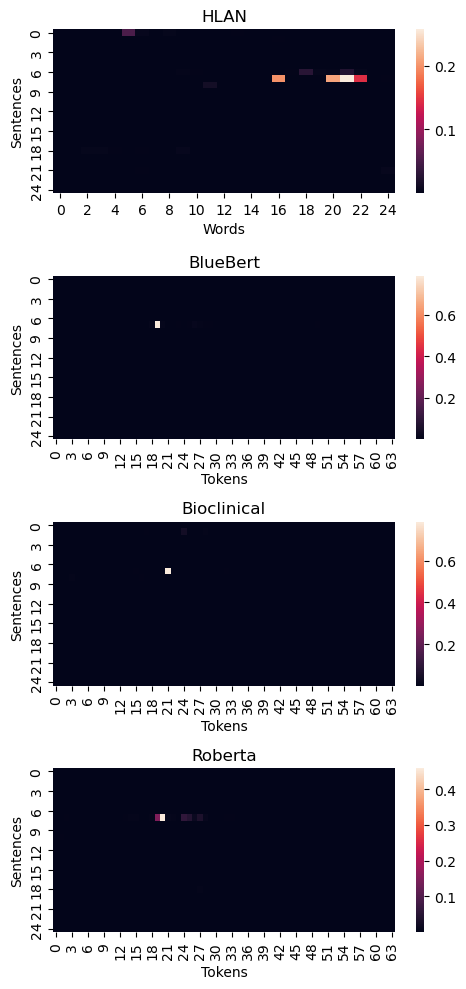

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5, 10))
sns.heatmap(hlan_attn_mat, ax=axes[0])
axes[0].set_title('HLAN')
axes[0].set_xlabel('Words') 
axes[0].set_ylabel('Sentences') 

# Plot the second heatmap
sns.heatmap(bluebert_attn_mat, ax=axes[1]) 
axes[1].set_xlabel('Tokens')  
axes[1].set_ylabel('Sentences') 
axes[1].set_title('BlueBert')

# Plot the third heatmap (Bioclinical)
sns.heatmap(bioclinical_attn_mat, ax=axes[2]) 
axes[2].set_xlabel('Tokens')  
axes[2].set_ylabel('Sentences')  
axes[2].set_title('Bioclinical')

# Plot the fourth heatmap (Roberta)
sns.heatmap(roberta_attn_mat, ax=axes[3])  
axes[3].set_title('Roberta')
axes[3].set_xlabel('Tokens')  
axes[3].set_ylabel('Sentences') 

# Display the plots
plt.tight_layout()
plt.show()